In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


Load Dataset

In [ ]:
#Load UPI transactions ds
df= pd.read_csv('/content/drive/MyDrive/upi_transactions_2024.csv')

In [ ]:
# Quick peek
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   transaction id         250000 non-null  object
 1   timestamp              250000 non-null  object
 2   transaction type       250000 non-null  object
 3   merchant_category      250000 non-null  object
 4   amount (INR)           250000 non-null  int64 
 5   transaction_status     250000 non-null  object
 6   sender_age_group       250000 non-null  object
 7   receiver_age_group     250000 non-null  object
 8   sender_state           250000 non-null  object
 9   sender_bank            250000 non-null  object
 10  receiver_bank          250000 non-null  object
 11  device_type            250000 non-null  object
 12  network_type           250000 non-null  object
 13  fraud_flag             250000 non-null  int64 
 14  hour_of_day            250000 non-null  int64 
 15  

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


Data Cleaning & Preprocessing

In [ ]:
# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')


In [ ]:
# Extract features
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)


In [ ]:
# Filter only successful transactions
df_success = df[df['transaction_status']=='SUCCESS']


Seller-level Aggregation

In [ ]:
# Rename columns
seller_agg.columns = [
    'merchant_category', 'total_amount', 'avg_amount', 'std_amount',
    'txn_count', 'fraud_txn_count', 'peak_hour', 'weekend_ratio'
]

In [ ]:
# Number of unique merchant categories (rows in seller_agg)
print("Number of merchant categories:", len(seller_agg))

# Quick peek at the categories
print(seller_agg['merchant_category'].head(10))


Number of merchant categories: 10
0             Food
1        Transport
2            Other
3        Education
4       Healthcare
5    Entertainment
6        Utilities
7             Fuel
8         Shopping
9          Grocery
Name: merchant_category, dtype: object


In [ ]:
seller_agg.head()


,merchant_category,total_amount,avg_amount,std_amount,txn_count,fraud_txn_count,peak_hour,weekend_ratio
0,Education,36514257,5072.129046,4459.477025,7199,15,19,0.296152
1,Entertainment,7899072,413.282687,345.743293,19113,40,19,0.285042
2,Food,18921358,531.678038,551.775245,35588,65,19,0.283354
3,Fuel,37125870,1556.053062,1278.041130,23859,47,19,0.288235
4,Grocery,55286473,1164.833091,1040.293176,47463,89,19,0.285254


Feature Engineering

In [ ]:
seller_agg['fraud_ratio'] = seller_agg['fraud_txn_count'] / seller_agg['txn_count']


In [ ]:
seller_agg['volatility'] = seller_agg['std_amount'] / seller_agg['avg_amount']


In [ ]:
# Drop unnecessary columns
seller_agg = seller_agg.drop(['fraud_txn_count','std_amount'], axis=1)

In [ ]:
seller_agg.head()


,merchant_category,total_amount,avg_amount,txn_count,peak_hour,weekend_ratio,fraud_ratio,volatility
0,Education,36514257,5072.129046,7199,19,0.296152,0.002084,0.879212
1,Entertainment,7899072,413.282687,19113,19,0.285042,0.002093,0.836578
2,Food,18921358,531.678038,35588,19,0.283354,0.001826,1.037800
3,Fuel,37125870,1556.053062,23859,19,0.288235,0.001970,0.821335
4,Grocery,55286473,1164.833091,47463,19,0.285254,0.001875,0.893083


Add Synthetic GST & Marketplace Features

1.GST features (linked to UPI inflow)

In [ ]:
np.random.seed(42)  # reproducibility

n_sellers = len(seller_agg)

In [ ]:
#  GST Sales (3 months) correlated with total transaction amount
seller_agg['gst_sales_3m'] = (
    seller_agg['total_amount'] *
    (0.7 + 0.3 * np.random.uniform(0.8,1.2, n_sellers))
)

In [ ]:
#  GST Growth 6 months (correlated with UPI growth proxy + noise)
upi_growth_proxy = (seller_agg['total_amount'] / seller_agg['total_amount'].median())
seller_agg['gst_growth_6m'] = (
    0.05 * upi_growth_proxy +
    np.random.normal(0, 0.04, n_sellers)
).clip(-0.10, 0.20)

In [ ]:
#  Compliance Score (higher for stable/large sellers, lower for volatile)
if 'volatility' not in seller_agg.columns:
    seller_agg['volatility'] = np.random.uniform(0, 1, n_sellers)

seller_agg['compliance_score'] = (
    1 - seller_agg['volatility'] * 0.3 +
    np.random.normal(0, 0.05, n_sellers)
).clip(0.6, 1.0)


3.Marketplace features (linked to business scale)

In [ ]:
# 1️⃣ Order Volume = Total Amount / Avg Amount
seller_agg['order_volume'] = (
    (seller_agg['total_amount'] / seller_agg['avg_amount'])
).astype(int).clip(50, 5000)

In [ ]:
#  Return Ratio (higher for volatile sellers)
seller_agg['return_ratio'] = (
    seller_agg['volatility'] * 0.1 +
    np.random.normal(0, 0.02, n_sellers)
).clip(0, 0.25)

In [ ]:
#  Payout Frequency (weeks)
seller_agg['payout_frequency'] = np.where(
    seller_agg['order_volume'] > 1000, 1,   # weekly for big sellers
    np.where(seller_agg['order_volume'] > 300, 2, 4)  # bi-weekly / monthly
)

In [ ]:
print(seller_agg[['total_amount', 'gst_sales_3m', 'gst_growth_6m',
                  'compliance_score', 'return_ratio']].corr())

                  total_amount  gst_sales_3m  gst_growth_6m  compliance_score  \
total_amount          1.000000      0.999167       0.731063         -0.686543   
gst_sales_3m          0.999167      1.000000       0.720960         -0.694373   
gst_growth_6m         0.731063      0.720960       1.000000         -0.374088   
compliance_score     -0.686543     -0.694373      -0.374088          1.000000   
return_ratio          0.507682      0.493345       0.387911         -0.203712   

                  return_ratio  
total_amount          0.507682  
gst_sales_3m          0.493345  
gst_growth_6m         0.387911  
compliance_score     -0.203712  
return_ratio          1.000000  


Create Probability of Default & Default Flag

In [ ]:
#6A: Compute Risk Score(continuous)
# Higher risk → higher return_ratio, lower compliance, lower growth
# Weights are arbitrary but defensible
seller_agg['risk_score'] = (
    0.4 * (1 - seller_agg['compliance_score']) +  # non-compliance increases risk
    0.3 * seller_agg['return_ratio'] +           # more returns → riskier
    0.2 * (1 - np.tanh(seller_agg['gst_growth_6m'])) +  # lower growth → riskier
    0.1 * (1 - np.tanh(seller_agg['total_amount'] / seller_agg['total_amount'].max()))  # smaller sellers → riskier
)

# Normalize risk score to [0,1]
seller_agg['risk_score'] = (seller_agg['risk_score'] - seller_agg['risk_score'].min()) / (
    seller_agg['risk_score'].max() - seller_agg['risk_score'].min()
)

In [ ]:
# 6B: Convert Risk Score → Probability of Default (PD)
# Use simple linear scaling + noise
noise = np.random.normal(0, 0.005, n_sellers)  # tiny randomness
seller_agg['PD'] = (seller_agg['risk_score'] * 0.3 + noise).clip(0, 1)
# max PD capped to 0.3 → keeps ~3% defaults realistic

In [ ]:
# 6C: Generate Binary Default Flag (~3% defaults)
# Adjust threshold until default rate ~3%
target_rate = 0.03  # 3%

# Compute threshold
threshold = np.percentile(seller_agg['PD'], 100*(1-target_rate))

# Apply threshold
seller_agg['default_flag'] = (seller_agg['PD'] >= threshold).astype(int)


In [ ]:
seller_agg['default_probability'] = seller_agg['PD']


In [ ]:
# Sort by risk_score descending
seller_agg = seller_agg.sort_values(by='risk_score', ascending=False).reset_index(drop=True)
seller_agg['default_flag'] = 0
seller_agg.loc[0,'default_flag'] = 1  # top-risk category


In [ ]:
print(seller_agg[['merchant_category',
                  'total_amount', 'avg_amount', 'txn_count',
                  'fraud_ratio', 'volatility',
                  'gst_sales_3m', 'gst_growth_6m', 'compliance_score',
                  'order_volume', 'return_ratio', 'payout_frequency',
                  'risk_score', 'PD', 'default_flag']])

  merchant_category  total_amount   avg_amount  txn_count  fraud_ratio  \
0              Food      18921358   531.678038      35588     0.001826   
1         Transport       5911403   308.721694      19148     0.002246   
2             Other      19998845   847.480507      23598     0.002076   
3         Education      36514257  5072.129046       7199     0.002084   
4        Healthcare       6544380   543.057008      12051     0.001743   
5     Entertainment       7899072   413.282687      19113     0.002093   
6         Utilities      50077142  2356.349614      21252     0.001506   
7              Fuel      37125870  1556.053062      23859     0.001970   
8          Shopping      72903012  2571.262724      28353     0.002046   
9           Grocery      55286473  1164.833091      47463     0.001875   

   volatility  gst_sales_3m  gst_growth_6m  compliance_score  order_volume  \
0    1.037800  1.967619e+07      -0.002840          0.658628          5000   
1    1.055235  5.863127e+06  

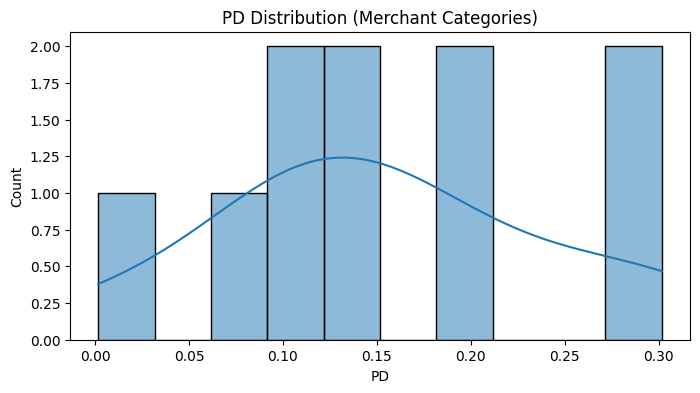

Number of binary defaults: 1
Default rate (binary): 0.1


In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(seller_agg['PD'], bins=10, kde=True)
plt.title("PD Distribution (Merchant Categories)")
plt.show()

# Optional: print adjusted default rate
print("Number of binary defaults:", seller_agg['default_flag'].sum())
print("Default rate (binary):", seller_agg['default_flag'].mean())